# Lesson 5B-1: Time Value of Money, Interest Rates, and Bonds

**Probability, Statistics and Econometrics for Finance, Accounting and Economics**  
**Instructor:** Matthew L. Kelly, PhD  
**Lesson sequence:** Finance valuation module, Part I

This notebook develops the time value of money and bond valuation from first principles. The goal is to show that all present value formulas are special cases of one idea: a dollar received in the future is worth less today because capital has an opportunity cost.

## Learning objectives

By the end of this lecture, students should be able to:

1. Derive and use present value formulas for non-constant cash flows, level cash flows, annuities, growing annuities, perpetuities, and growing perpetuities.
2. Compute net present value, internal rate of return, modified internal rate of return, equivalent annual annuity, and crossover rates.
3. Value coupon bonds with annual, semiannual, quarterly, or monthly coupons.
4. Explain discount bonds, par bonds, premium bonds, credit spreads, default risk, nominal and real rates, and the Fisher equation.
5. Use duration and convexity to approximate bond-price sensitivity.
6. Interpret the yield curve using real rates, expected inflation, term premia, level, slope, and curvature.
7. Identify simple fixed-income arbitrage opportunities using bonds of different maturities.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:,.4f}".format


## 1. The single organizing principle: present value

Let $CF_t$ denote a cash flow received at date $t$. If the per-period discount rate is $r$, its present value is

$$
PV_t = \frac{CF_t}{(1+r)^t}.
$$

For any finite sequence of cash flows, the present value is simply the sum of the discounted cash flows:

$$
PV = \sum_{t=1}^{T} \frac{CF_t}{(1+r)^t}.
$$

Every formula in this lecture is a special case of this expression. The only thing that changes is the pattern of the cash flows.


In [2]:
def pv_cashflows(cashflows, r):
    """Present value of a sequence of cash flows at end-of-period dates 1,...,T."""
    cashflows = np.asarray(cashflows, dtype=float)
    periods = np.arange(1, len(cashflows) + 1)
    return np.sum(cashflows / (1 + r) ** periods)

cashflows = [100, 50, 200, 300]
r = 0.08
print(f"PV of non-constant cash flows at r={r:.1%}: ${pv_cashflows(cashflows, r):,.2f}")


PV of non-constant cash flows at r=8.0%: $514.73


## 2. Compounding and discounting

If $PV$ is invested for $t$ periods at rate $r$, the future value is

$$
FV_t = PV(1+r)^t.
$$

Solving for $PV$ gives the present value formula:

$$
PV = \frac{FV_t}{(1+r)^t}.
$$

If a quoted annual percentage rate is compounded $m$ times per year, the effective annual rate is

$$
EAR = \left(1 + \frac{APR}{m}\right)^m - 1.
$$

With continuous compounding,

$$
FV_t = PV e^{rt}, \qquad PV = FV_t e^{-rt}.
$$


In [3]:
PV = 1000
apr = 0.12
for m in [1, 2, 4, 12, 365]:
    ear = (1 + apr/m)**m - 1
    print(f"APR={apr:.1%}, compounding periods={m:>3}: EAR={ear:.4%}, FV after 1 year=${PV*(1+ear):,.2f}")

continuous_fv = PV * np.exp(apr)
print(f"Continuous compounding FV after 1 year: ${continuous_fv:,.2f}")


APR=12.0%, compounding periods=  1: EAR=12.0000%, FV after 1 year=$1,120.00
APR=12.0%, compounding periods=  2: EAR=12.3600%, FV after 1 year=$1,123.60
APR=12.0%, compounding periods=  4: EAR=12.5509%, FV after 1 year=$1,125.51
APR=12.0%, compounding periods= 12: EAR=12.6825%, FV after 1 year=$1,126.83
APR=12.0%, compounding periods=365: EAR=12.7475%, FV after 1 year=$1,127.47
Continuous compounding FV after 1 year: $1,127.50


## 3. Non-constant cash flows

The most general finite-case valuation formula is

$$
PV = \frac{CF_1}{1+r} + \frac{CF_2}{(1+r)^2} + \cdots + \frac{CF_T}{(1+r)^T}.
$$

This form is used for capital budgeting, bonds with unusual payment structures, leases, mortgage schedules, and multi-stage stock valuation.


In [4]:
project_cf = pd.DataFrame({
    "Year": [0, 1, 2, 3, 4, 5],
    "Cash Flow": [-500, 80, 120, 160, 220, 300]
})
project_cf["Discount Factor at 10%"] = 1 / (1.10) ** project_cf["Year"]
project_cf["Present Value"] = project_cf["Cash Flow"] * project_cf["Discount Factor at 10%"]
print(project_cf)
print(f"NPV: ${project_cf['Present Value'].sum():,.2f}")


   Year  Cash Flow  Discount Factor at 10%  Present Value
0     0       -500                  1.0000      -500.0000
1     1         80                  0.9091        72.7273
2     2        120                  0.8264        99.1736
3     3        160                  0.7513       120.2104
4     4        220                  0.6830       150.2630
5     5        300                  0.6209       186.2764
NPV: $128.65


## 4. Constant cash flows: annuities

An annuity pays a constant amount $C$ for $T$ periods. Its present value is

$$
PV = \sum_{t=1}^{T} \frac{C}{(1+r)^t}.
$$

This is a finite geometric series. Let $x = \frac{1}{1+r}$. Then

$$
PV = C(x + x^2 + \cdots + x^T).
$$

The finite geometric sum is

$$
x + x^2 + \cdots + x^T = \frac{x(1-x^T)}{1-x}.
$$

Substituting $x=1/(1+r)$ gives the ordinary annuity formula:

$$
PV_{\text{annuity}} = C \left[\frac{1 - (1+r)^{-T}}{r}\right].
$$

The future value of an annuity is

$$
FV_{\text{annuity}} = C\left[\frac{(1+r)^T - 1}{r}\right].
$$


In [5]:
def pv_annuity(C, r, T):
    return C * (1 - (1 + r) ** (-T)) / r

def fv_annuity(C, r, T):
    return C * ((1 + r) ** T - 1) / r

C, r, T = 1000, 0.06, 10
print(f"PV of ${C:,.0f} paid for {T} years at {r:.1%}: ${pv_annuity(C,r,T):,.2f}")
print(f"FV of ${C:,.0f} paid for {T} years at {r:.1%}: ${fv_annuity(C,r,T):,.2f}")

# Check against direct summation
print(f"Direct summation check: ${pv_cashflows([C]*T, r):,.2f}")


PV of $1,000 paid for 10 years at 6.0%: $7,360.09
FV of $1,000 paid for 10 years at 6.0%: $13,180.79
Direct summation check: $7,360.09


## 5. Perpetuities and growing cash flows

A perpetuity pays $C$ forever. Since

$$
PV = \sum_{t=1}^{\infty} \frac{C}{(1+r)^t},
$$

the infinite geometric series yields

$$
PV_{\text{perpetuity}} = \frac{C}{r}.
$$

A growing perpetuity pays $C_1$ next period and grows forever at rate $g$. Its present value is

$$
PV = \sum_{t=1}^{\infty} \frac{C_1(1+g)^{t-1}}{(1+r)^t}.
$$

Provided $r>g$, this simplifies to

$$
PV_{\text{growing perpetuity}} = \frac{C_1}{r-g}.
$$

A growing annuity is the finite version:

$$
PV_{\text{growing annuity}} = \frac{C_1}{r-g}\left[1 - \left(\frac{1+g}{1+r}\right)^T\right], \qquad r \ne g.
$$


In [6]:
def pv_perpetuity(C, r):
    return C / r

def pv_growing_perpetuity(C1, r, g):
    if r <= g:
        raise ValueError("The discount rate must exceed the growth rate.")
    return C1 / (r - g)

def pv_growing_annuity(C1, r, g, T):
    if abs(r-g) < 1e-12:
        return T * C1 / (1 + r)
    return C1 / (r - g) * (1 - ((1 + g) / (1 + r)) ** T)

print(f"PV perpetuity: ${pv_perpetuity(100, .05):,.2f}")
print(f"PV growing perpetuity: ${pv_growing_perpetuity(100, .08, .03):,.2f}")
print(f"PV growing annuity: ${pv_growing_annuity(100, .08, .03, 10):,.2f}")


PV perpetuity: $2,000.00
PV growing perpetuity: $2,000.00
PV growing annuity: $755.01


## 6. NPV, IRR, MIRR, and crossover rates

The net present value of an investment with initial cost $C_0$ and future cash flows $CF_t$ is

$$
NPV(r) = C_0 + \sum_{t=1}^{T}\frac{CF_t}{(1+r)^t}.
$$

A project should be accepted if $NPV>0$, because it creates value relative to the opportunity cost of capital.

The internal rate of return is the discount rate that sets NPV equal to zero:

$$
0 = C_0 + \sum_{t=1}^{T}\frac{CF_t}{(1+IRR)^t}.
$$

IRR is useful, but it can mislead when projects differ in scale, timing, or have non-conventional cash flows with multiple sign changes.

The modified internal rate of return separates the financing rate from the reinvestment rate:

$$
MIRR = \left(\frac{FV(\text{positive cash flows reinvested})}{PV(\text{negative cash flows financed})}\right)^{1/T} - 1.
$$

The crossover rate is the discount rate at which two projects have equal NPV:

$$
NPV_A(r) = NPV_B(r).
$$


In [7]:
def npv(rate, cfs):
    cfs = np.asarray(cfs, dtype=float)
    t = np.arange(len(cfs))
    return np.sum(cfs / (1 + rate) ** t)

def irr(cfs, low=-0.999, high=10):
    return brentq(lambda r: npv(r, cfs), low, high)

def mirr(cfs, finance_rate, reinvest_rate):
    cfs = np.asarray(cfs, dtype=float)
    T = len(cfs) - 1
    pv_neg = sum(cf / (1 + finance_rate)**t for t, cf in enumerate(cfs) if cf < 0)
    fv_pos = sum(cf * (1 + reinvest_rate)**(T-t) for t, cf in enumerate(cfs) if cf > 0)
    return (fv_pos / abs(pv_neg)) ** (1/T) - 1

project_A = [-1000, 500, 450, 350, 250]
project_B = [-1000, 100, 250, 500, 800]
for name, cfs in [('A', project_A), ('B', project_B)]:
    print(f"Project {name}: NPV at 10% = ${npv(.10,cfs):,.2f}, IRR = {irr(cfs):.2%}, MIRR = {mirr(cfs,.08,.10):.2%}")

crossover = brentq(lambda r: npv(r, project_A) - npv(r, project_B), -0.50, 1.00)
print(f"Crossover rate: {crossover:.2%}")


Project A: NPV at 10% = $260.16, IRR = 23.08%, MIRR = 16.55%
Project B: NPV at 10% = $219.59, IRR = 17.27%, MIRR = 15.60%
Crossover rate: 6.48%


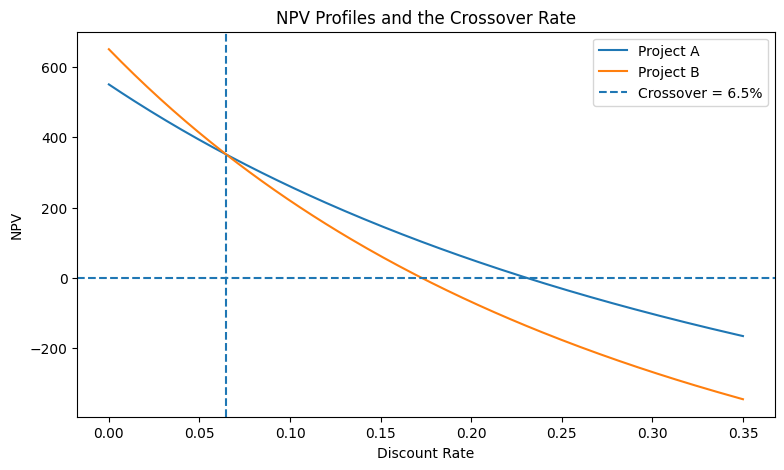

In [8]:
rates = np.linspace(0, .35, 200)
npv_A = [npv(r, project_A) for r in rates]
npv_B = [npv(r, project_B) for r in rates]
plt.figure(figsize=(9,5))
plt.plot(rates, npv_A, label='Project A')
plt.plot(rates, npv_B, label='Project B')
plt.axhline(0, linestyle='--')
plt.axvline(crossover, linestyle='--', label=f'Crossover = {crossover:.1%}')
plt.title('NPV Profiles and the Crossover Rate')
plt.xlabel('Discount Rate')
plt.ylabel('NPV')
plt.legend()
plt.show()



### 6.1 When IRR works well, and when it fails

IRR is most reliable for **conventional** investment projects: an initial cash outflow followed by cash inflows with exactly one sign change. In that case the NPV profile usually crosses zero once, so the IRR has a straightforward interpretation: it is the break-even discount rate.

IRR becomes unreliable when cash flows are **non-normal**, meaning the sign changes more than once. For example, a mining project may require an initial investment, generate cash inflows for several years, and then require a large environmental cleanup cost at the end. The NPV equation is then a polynomial in the discount factor,

$$
NPV(r)=\sum_{t=0}^{T}\frac{CF_t}{(1+r)^t}=0.
$$

Let

$$
x=\frac{1}{1+r}.
$$

Then the IRR problem becomes

$$
CF_0+CF_1x+CF_2x^2+\cdots+CF_Tx^T=0.
$$

That polynomial can have several roots. Some imply real IRRs. Others are complex-valued and have no direct economic interpretation as ordinary rates of return. This is why NPV is usually the safer capital-budgeting criterion: NPV asks whether the asset creates dollar value at the relevant opportunity cost of capital, while IRR asks for a root of a polynomial that may have several roots.


In [9]:

def all_irr_roots(cashflows):
    """Return all complex IRR roots implied by the cash-flow polynomial.

    Uses x = 1/(1+r). The NPV equation is sum_t CF_t x^t = 0.
    Roots in x are converted to roots in r by r = 1/x - 1.
    """
    cfs = np.asarray(cashflows, dtype=float)
    # np.roots expects highest power first: CF_T x^T + ... + CF_0
    x_roots = np.roots(cfs[::-1])
    r_roots = 1 / x_roots - 1
    return r_roots

def real_economic_irrs(cashflows, tol=1e-8):
    roots = all_irr_roots(cashflows)
    real_roots = [z.real for z in roots if abs(z.imag) < tol and z.real > -1]
    return sorted(real_roots)

examples = {
    "Conventional project": [-1000, 350, 400, 450, 500],
    "Scale problem: small high-IRR project": [-10, 20],
    "Scale problem: large lower-IRR project": [-1000, 1500],
    "Non-normal project with multiple IRRs": [-1000, 5000, -6000, 2500],
    "Cleanup-cost project": [-1000, 700, 700, 700, -900]
}

rows = []
for name, cfs in examples.items():
    roots = all_irr_roots(cfs)
    real_roots = real_economic_irrs(cfs)
    rows.append({
        "Example": name,
        "Cash flows": cfs,
        "NPV at 10%": npv(0.10, cfs),
        "Number of real IRRs > -100%": len(real_roots),
        "Real IRRs": ", ".join(f"{r:.2%}" for r in real_roots) if real_roots else "None"
    })

pd.DataFrame(rows)


,Example,Cash flows,NPV at 10%,Number of real IRRs > -100%,Real IRRs
0,Conventional project,"[-1000, 350, 400, 450, 500]",328.3587,1,23.47%
1,Scale problem: small high-IRR project,"[-10, 20]",8.1818,1,100.00%
2,Scale problem: large lower-IRR project,"[-1000, 1500]",363.6364,1,50.00%
3,Non-normal project with multiple IRRs,"[-1000, 5000, -6000, 2500]",465.0639,1,248.37%
4,Cleanup-cost project,"[-1000, 700, 700, 700, -900]",126.0843,2,"-24.81%, 24.74%"


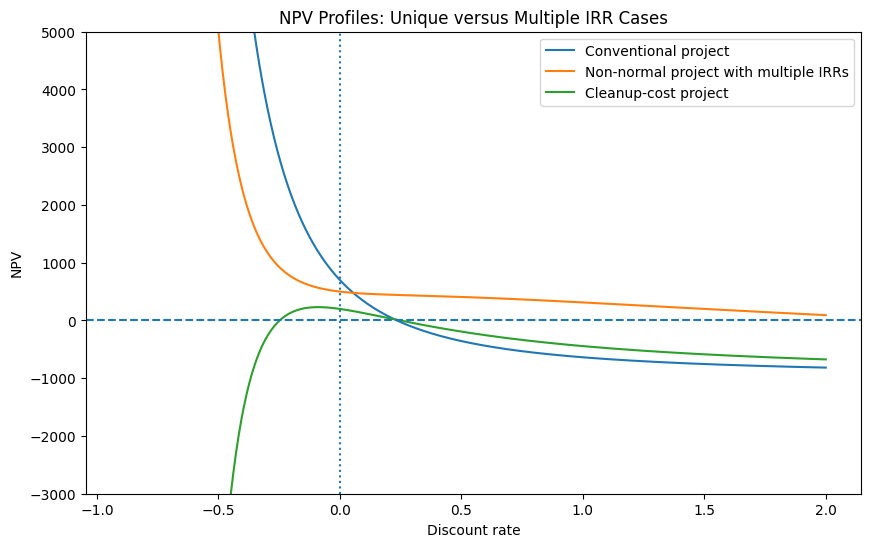

In [10]:

# Plot NPV profiles for a conventional project and a non-normal project.
rates = np.linspace(-0.90, 2.00, 800)
plt.figure(figsize=(10, 6))
for name in ["Conventional project", "Non-normal project with multiple IRRs", "Cleanup-cost project"]:
    cfs = examples[name]
    values = [npv(r, cfs) if r > -1 else np.nan for r in rates]
    plt.plot(rates, values, label=name)
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle=':')
plt.ylim(-3000, 5000)
plt.title("NPV Profiles: Unique versus Multiple IRR Cases")
plt.xlabel("Discount rate")
plt.ylabel("NPV")
plt.legend()
plt.show()



### 6.2 Complex IRR roots and the complex plane

For a project with $T$ dated cash flows after date 0, the IRR equation is a degree-$T$ polynomial in $x=1/(1+r)$. The fundamental theorem of algebra says that this polynomial has $T$ roots in the complex plane, counting multiplicity. Only real roots with $r>-1$ are candidates for ordinary economic IRRs.

It is sometimes tempting to search for an economic meaning in all of the roots. The important point is more modest: complex roots reveal that IRR is fundamentally a polynomial-root problem, not a primitive measure of value. Duration, by contrast, is not a product of polynomial roots. Duration is a present-value-weighted average timing of cash flows:

$$
D_{Mac}=\sum_{t=1}^{N} t\frac{PV(CF_t)}{P}.
$$

By Vieta's formula, products of polynomial roots are governed by the first and last cash-flow coefficients. For the discount-factor roots $x_i$,

$$
\prod_{i=1}^{T}x_i=(-1)^T\frac{CF_0}{CF_T}.
$$

That identity is useful algebraically, but it is not a duration formula. The comparison below is included to show the difference between root algebra and bond-price sensitivity.


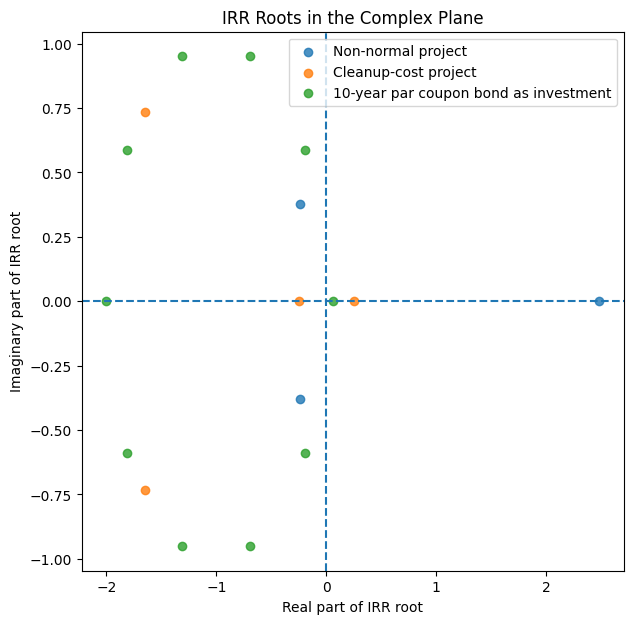

,Maturity,Coupon rate,YTM,Price,Real economic IRR,Macaulay duration,Product of all (1+IRR roots),Imaginary part of product
0,2,0.0200,0.0500,944.2177,0.0500,1.9798,-1.0803,0.0000
1,5,0.0600,0.0500,"1,043.2948",0.0500,4.4778,1.0160,0.0000
2,10,0.0600,0.0600,"1,000.0000",0.0600,7.8017,-1.0600,0.0000
3,30,0.0300,0.0500,692.5510,0.0500,17.9931,-1.4873,-0.0000
4,30,0.1000,0.0500,"1,768.6226",0.0500,14.3280,-0.6220,-0.0000


In [11]:

# Complex-plane diagram for IRR roots.
complex_examples = {
    "Non-normal project": examples["Non-normal project with multiple IRRs"],
    "Cleanup-cost project": examples["Cleanup-cost project"],
    "10-year par coupon bond as investment": [-1000] + [60]*9 + [1060]
}

plt.figure(figsize=(7, 7))
for name, cfs in complex_examples.items():
    roots = all_irr_roots(cfs)
    plt.scatter([z.real for z in roots], [z.imag for z in roots], label=name, alpha=0.8)
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title("IRR Roots in the Complex Plane")
plt.xlabel("Real part of IRR root")
plt.ylabel("Imaginary part of IRR root")
plt.legend()
plt.show()

# Compare root products with Macaulay duration for several bonds.

def simple_bond_price(face=1000, coupon_rate=0.06, ytm=0.05, maturity=10, freq=1):
    n = int(round(maturity * freq))
    coupon = face * coupon_rate / freq
    y_period = ytm / freq
    return sum(coupon / (1 + y_period)**t for t in range(1, n + 1)) + face / (1 + y_period)**n

def bond_investment_cashflows(price, face=1000, coupon_rate=0.06, maturity=10, freq=1):
    n = int(round(maturity * freq))
    coupon = face * coupon_rate / freq
    return [-price] + [coupon] * (n - 1) + [coupon + face]

def macaulay_duration_from_cashflows(cfs, y):
    cfs = np.asarray(cfs, dtype=float)
    future = cfs[1:]
    t = np.arange(1, len(cfs))
    pv = future / (1 + y) ** t
    price = pv.sum()
    return np.sum(t * pv) / price

bond_rows = []
for maturity, coupon_rate, y in [(2, 0.02, 0.05), (5, 0.06, 0.05), (10, 0.06, 0.06), (30, 0.03, 0.05), (30, 0.10, 0.05)]:
    price = simple_bond_price(face=1000, coupon_rate=coupon_rate, ytm=y, maturity=maturity, freq=1)
    cfs = bond_investment_cashflows(price, 1000, coupon_rate, maturity, 1)
    irr_roots = all_irr_roots(cfs)
    product_1_plus_r = np.prod(1 + irr_roots)
    mac_dur = macaulay_duration_from_cashflows(cfs, y)
    bond_rows.append({
        "Maturity": maturity,
        "Coupon rate": coupon_rate,
        "YTM": y,
        "Price": price,
        "Real economic IRR": real_economic_irrs(cfs)[0],
        "Macaulay duration": mac_dur,
        "Product of all (1+IRR roots)": product_1_plus_r.real,
        "Imaginary part of product": product_1_plus_r.imag
    })

pd.DataFrame(bond_rows)


## 7. Bond valuation from the same present value logic

A standard coupon bond pays periodic coupons plus face value at maturity. If coupons are paid $m$ times per year, the periodic coupon is

$$
\text{Coupon per period} = \frac{F c}{m},
$$

where $F$ is face value and $c$ is the annual coupon rate. If the yield to maturity is quoted as an annual rate $y$ with the same compounding frequency, the periodic discount rate is $y/m$. For maturity $T$ years, the number of coupon periods is $N=mT$.

The bond price is

$$
P = \sum_{t=1}^{N}\frac{Fc/m}{(1+y/m)^t} + \frac{F}{(1+y/m)^N}.
$$

Using the annuity formula,

$$
P = \frac{Fc}{m}\left[\frac{1-(1+y/m)^{-mT}}{y/m}\right] + \frac{F}{(1+y/m)^{mT}}.
$$


In [12]:
def bond_price(face=1000, coupon_rate=0.06, ytm=0.05, maturity=10, freq=2):
    N = int(round(maturity * freq))
    c = face * coupon_rate / freq
    period_y = ytm / freq
    return c * (1 - (1 + period_y) ** (-N)) / period_y + face / (1 + period_y) ** N

def bond_cashflows(face=1000, coupon_rate=0.06, maturity=10, freq=2):
    N = int(round(maturity * freq))
    c = face * coupon_rate / freq
    cfs = np.full(N, c)
    cfs[-1] += face
    return cfs

for freq in [1, 2, 4, 12]:
    price = bond_price(face=1000, coupon_rate=0.06, ytm=0.05, maturity=10, freq=freq)
    print(f"Coupon frequency {freq:>2}x per year: price = ${price:,.2f}")


Coupon frequency  1x per year: price = $1,077.22
Coupon frequency  2x per year: price = $1,077.95
Coupon frequency  4x per year: price = $1,078.32
Coupon frequency 12x per year: price = $1,078.57


## 8. Discount, par, and premium bonds

A bond sells at par when its coupon rate equals its yield to maturity. It sells at a premium when its coupon rate is above the yield, and at a discount when its coupon rate is below the yield.

$$
\begin{aligned}
 c = y &\Rightarrow P = F \quad \text{par bond}, \\
 c > y &\Rightarrow P > F \quad \text{premium bond}, \\
 c < y &\Rightarrow P < F \quad \text{discount bond}.
\end{aligned}
$$


In [13]:
rows = []
for coupon_rate in [0.03, 0.05, 0.08]:
    rows.append({
        'Coupon Rate': coupon_rate,
        'YTM': 0.05,
        'Price': bond_price(1000, coupon_rate, 0.05, 10, 2),
        'Type': 'Discount' if coupon_rate < .05 else ('Par' if coupon_rate == .05 else 'Premium')
    })
print(pd.DataFrame(rows))


   Coupon Rate    YTM      Price      Type
0       0.0300 0.0500   844.1084  Discount
1       0.0500 0.0500 1,000.0000       Par
2       0.0800 0.0500 1,233.8374   Premium


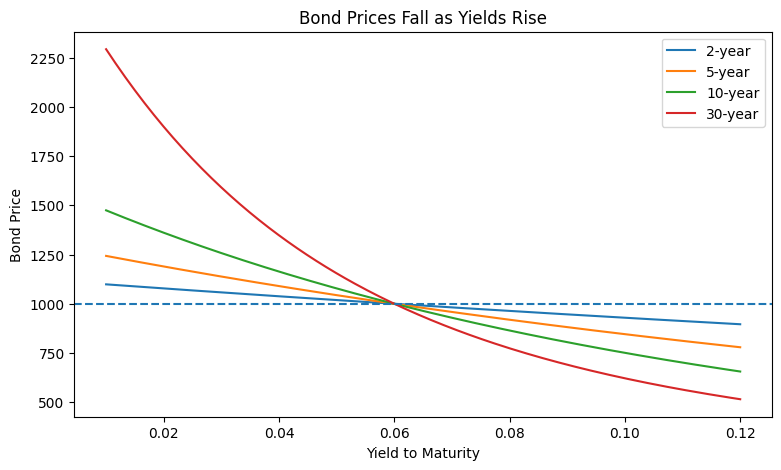

In [14]:
yields = np.linspace(0.01, 0.12, 200)
plt.figure(figsize=(9,5))
for maturity in [2, 5, 10, 30]:
    prices = [bond_price(1000, .06, y, maturity, 2) for y in yields]
    plt.plot(yields, prices, label=f'{maturity}-year')
plt.axhline(1000, linestyle='--')
plt.title('Bond Prices Fall as Yields Rise')
plt.xlabel('Yield to Maturity')
plt.ylabel('Bond Price')
plt.legend()
plt.show()


## 9. Yield to maturity and spot rates

The yield to maturity is the single discount rate that makes the present value of promised cash flows equal to the observed market price:

$$
P = \sum_{t=1}^{N}\frac{CF_t}{(1+y/m)^t}.
$$

Spot rates are zero-coupon yields for particular maturities. If $s_t$ is the annual spot rate for maturity $t$, the price of a default-free cash flow $CF_t$ received at $t$ is

$$
PV_t = \frac{CF_t}{(1+s_t)^t}.
$$

Using maturity-specific spot rates is more fundamental than discounting every cash flow at a single YTM.


In [15]:
def ytm_from_price(price, face=1000, coupon_rate=0.06, maturity=10, freq=2):
    cfs = bond_cashflows(face, coupon_rate, maturity, freq)
    N = len(cfs)
    def f(y):
        return np.sum(cfs / (1 + y/freq) ** np.arange(1, N+1)) - price
    return brentq(f, -0.95, 1.00)

price = 1_075
print(f"YTM for a 10-year 6% semiannual coupon bond priced at ${price:,.2f}: {ytm_from_price(price):.3%}")


YTM for a 10-year 6% semiannual coupon bond priced at $1,075.00: 5.036%


## 10. Nominal rates, real rates, and expected inflation

The Fisher equation links nominal rates, real rates, and expected inflation:

$$
1+i = (1+r)(1+\pi^e),
$$

where $i$ is the nominal rate, $r$ is the real rate, and $\pi^e$ is expected inflation. Approximately,

$$
i \approx r + \pi^e.
$$

For default-free nominal bonds, yields reflect real rates, expected inflation, and compensation for interest-rate risk. Corporate bonds add default compensation and other spreads.


In [16]:
real_rate = 0.015
expected_inflation = 0.025
nominal_exact = (1 + real_rate) * (1 + expected_inflation) - 1
nominal_approx = real_rate + expected_inflation
print(f"Exact nominal rate: {nominal_exact:.3%}")
print(f"Approximate nominal rate: {nominal_approx:.3%}")


Exact nominal rate: 4.037%
Approximate nominal rate: 4.000%


## 11. Corporate bonds, credit spreads, and default risk

A corporate bond yield can be decomposed conceptually as

$$
y_{corp} = y_{Treasury} + \text{credit spread} + \text{liquidity spread} + \text{tax/spread effects}.
$$

The credit spread compensates investors for expected default losses and for bearing default risk. Expected default loss depends on default probability and recovery:

$$
\text{Expected loss rate} \approx PD \times (1-RR),
$$

where $PD$ is default probability and $RR$ is recovery rate.

A risky zero-coupon bond with face value $F$ and risk-neutral default probability $q$ can be valued as

$$
P = \frac{(1-q)F + q(RR)F}{1+r_f}.
$$


In [17]:
face = 1000
rf = 0.04
pd_default = 0.03
recovery = 0.40
risky_zero_price = ((1-pd_default)*face + pd_default*recovery*face) / (1+rf)
risky_yield = face / risky_zero_price - 1
print(f"Risky zero price: ${risky_zero_price:,.2f}")
print(f"Implied risky yield: {risky_yield:.3%}")
print(f"Credit spread over Treasury: {risky_yield-rf:.3%}")


Risky zero price: $944.23
Implied risky yield: 5.906%
Credit spread over Treasury: 1.906%


## 12. Duration and convexity

Bond prices are nonlinear functions of yields. Duration gives a first-order approximation to price sensitivity; convexity gives a second-order correction.

The Macaulay duration of a bond is the present-value-weighted average time to receive cash flows:

$$
D_{Mac} = \sum_{t=1}^{N} \left(\frac{PV(CF_t)}{P}\right) \frac{t}{m}.
$$

Modified duration converts this into yield sensitivity:

$$
D_{Mod} = \frac{D_{Mac}}{1+y/m}.
$$

For a small yield change $\Delta y$,

$$
\frac{\Delta P}{P} \approx -D_{Mod}\Delta y.
$$

Convexity improves the approximation:

$$
\frac{\Delta P}{P} \approx -D_{Mod}\Delta y + \frac{1}{2}Convexity(\Delta y)^2.
$$


In [18]:
def bond_duration_convexity(face=1000, coupon_rate=0.06, ytm=0.05, maturity=10, freq=2):
    cfs = bond_cashflows(face, coupon_rate, maturity, freq)
    N = len(cfs)
    period_y = ytm / freq
    periods = np.arange(1, N+1)
    times = periods / freq
    pv = cfs / (1 + period_y) ** periods
    price = pv.sum()
    weights = pv / price
    macaulay = np.sum(weights * times)
    modified = macaulay / (1 + period_y)
    # annualized convexity using period formula adjusted by freq^2
    convexity = np.sum(pv * periods * (periods + 1) / (1 + period_y)**2) / price / (freq**2)
    return price, macaulay, modified, convexity

for coupon in [0.00, 0.03, 0.06, 0.10]:
    price, mac, mod, conv = bond_duration_convexity(coupon_rate=coupon, ytm=.06, maturity=10, freq=2)
    print(f"Coupon {coupon:.0%}: Price=${price:,.2f}, Macaulay={mac:.2f}, Modified={mod:.2f}, Convexity={conv:.2f}")


Coupon 0%: Price=$553.68, Macaulay=10.00, Modified=9.71, Convexity=98.97
Coupon 3%: Price=$776.84, Macaulay=8.50, Modified=8.25, Convexity=79.54
Coupon 6%: Price=$1,000.00, Macaulay=7.66, Modified=7.44, Convexity=68.77
Coupon 10%: Price=$1,297.55, Macaulay=7.00, Modified=6.79, Convexity=60.18


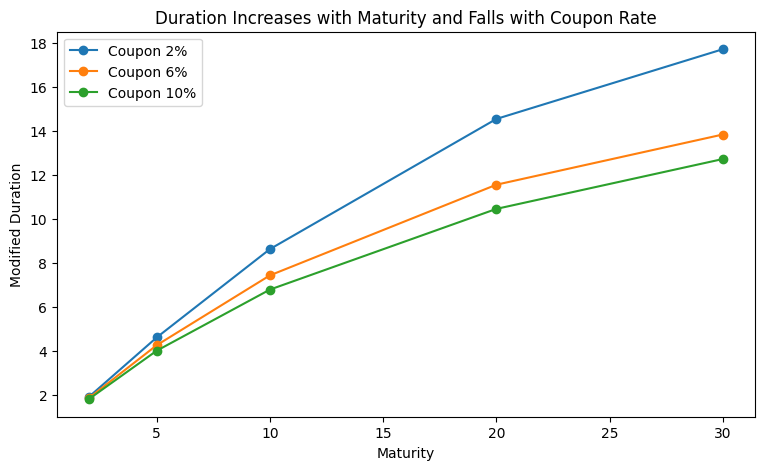

In [19]:
rows = []
for maturity in [2, 5, 10, 20, 30]:
    for coupon in [0.02, 0.06, 0.10]:
        price, mac, mod, conv = bond_duration_convexity(coupon_rate=coupon, ytm=.06, maturity=maturity, freq=2)
        rows.append({'Maturity': maturity, 'Coupon': coupon, 'Modified Duration': mod, 'Convexity': conv})
dc = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9,5))
for coupon, group in dc.groupby('Coupon'):
    ax.plot(group['Maturity'], group['Modified Duration'], marker='o', label=f'Coupon {coupon:.0%}')
ax.set_title('Duration Increases with Maturity and Falls with Coupon Rate')
ax.set_xlabel('Maturity')
ax.set_ylabel('Modified Duration')
ax.legend()
plt.show()


In [20]:
y0 = 0.06
face, coupon_rate, maturity, freq = 1000, .06, 10, 2
P0, mac, mod, conv = bond_duration_convexity(face, coupon_rate, y0, maturity, freq)
for dy in [-0.02, -0.01, 0.01, 0.02]:
    actual = bond_price(face, coupon_rate, y0+dy, maturity, freq)
    duration_approx = P0 * (1 - mod*dy)
    convexity_approx = P0 * (1 - mod*dy + 0.5*conv*dy**2)
    print(f"dy={dy:+.1%}: actual=${actual:,.2f}, duration=${duration_approx:,.2f}, duration+convexity=${convexity_approx:,.2f}")


dy=-2.0%: actual=$1,163.51, duration=$1,148.77, duration+convexity=$1,162.53
dy=-1.0%: actual=$1,077.95, duration=$1,074.39, duration+convexity=$1,077.83
dy=+1.0%: actual=$928.94, duration=$925.61, duration+convexity=$929.05
dy=+2.0%: actual=$864.10, duration=$851.23, duration+convexity=$864.98



### 12.1 Using duration and convexity to approximate bond-price changes

The exact bond price is a nonlinear function of the yield. Around an initial yield $y_0$, duration and convexity give a local approximation. If $\Delta y$ is a small change in the yield per compounding period convention, then

$$
\frac{\Delta P}{P}\approx -D_{mod}\Delta y + \frac{1}{2}C(\Delta y)^2,
$$

where $D_{mod}$ is modified duration and $C$ is convexity. The first term is the straight-line duration approximation. The second term corrects for the curvature of the price-yield relationship.

Duration alone is usually good for small yield changes. Duration plus convexity is better for larger yield changes, especially for long-maturity, low-coupon bonds.


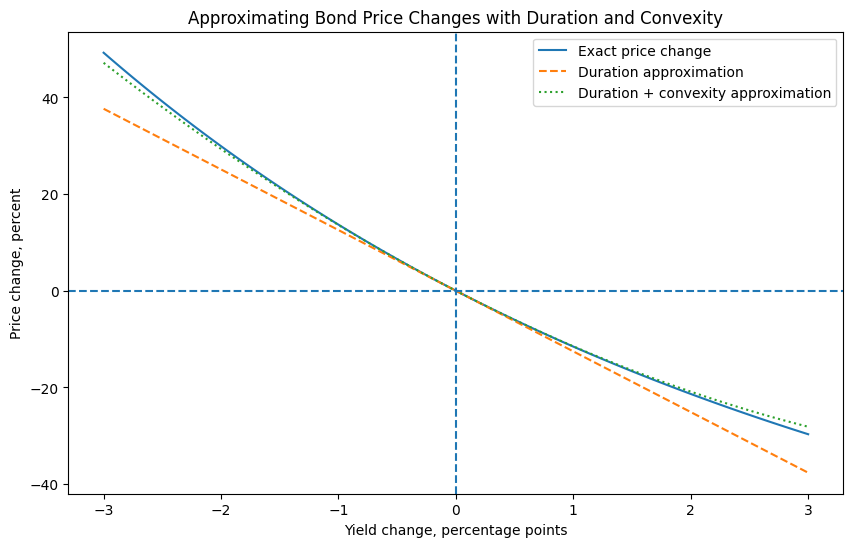

Base price: $1,000.00
Macaulay duration: 12.87 years
Modified duration: 12.55
Convexity: 211.38


In [21]:

# Exact price change versus duration and duration-plus-convexity approximations.
base_face = 1000
base_coupon = 0.05
base_maturity = 20
base_freq = 2
base_yield = 0.05
P0, mac0, mod0, conv0 = bond_duration_convexity(base_face, base_coupon, base_yield, base_maturity, base_freq)

yield_changes = np.linspace(-0.03, 0.03, 121)
exact_pct_changes = []
duration_approx = []
convexity_approx = []
for dy in yield_changes:
    P_new = bond_price(base_face, base_coupon, base_yield + dy, base_maturity, base_freq)
    exact = (P_new - P0) / P0
    dur_only = -mod0 * dy
    dur_conv = -mod0 * dy + 0.5 * conv0 * dy**2
    exact_pct_changes.append(exact)
    duration_approx.append(dur_only)
    convexity_approx.append(dur_conv)

plt.figure(figsize=(10, 6))
plt.plot(yield_changes * 100, np.array(exact_pct_changes) * 100, label="Exact price change")
plt.plot(yield_changes * 100, np.array(duration_approx) * 100, linestyle='--', label="Duration approximation")
plt.plot(yield_changes * 100, np.array(convexity_approx) * 100, linestyle=':', label="Duration + convexity approximation")
plt.axhline(0, linestyle='--')
plt.axvline(0, linestyle='--')
plt.title("Approximating Bond Price Changes with Duration and Convexity")
plt.xlabel("Yield change, percentage points")
plt.ylabel("Price change, percent")
plt.legend()
plt.show()

print(f"Base price: ${P0:,.2f}")
print(f"Macaulay duration: {mac0:.2f} years")
print(f"Modified duration: {mod0:.2f}")
print(f"Convexity: {conv0:.2f}")


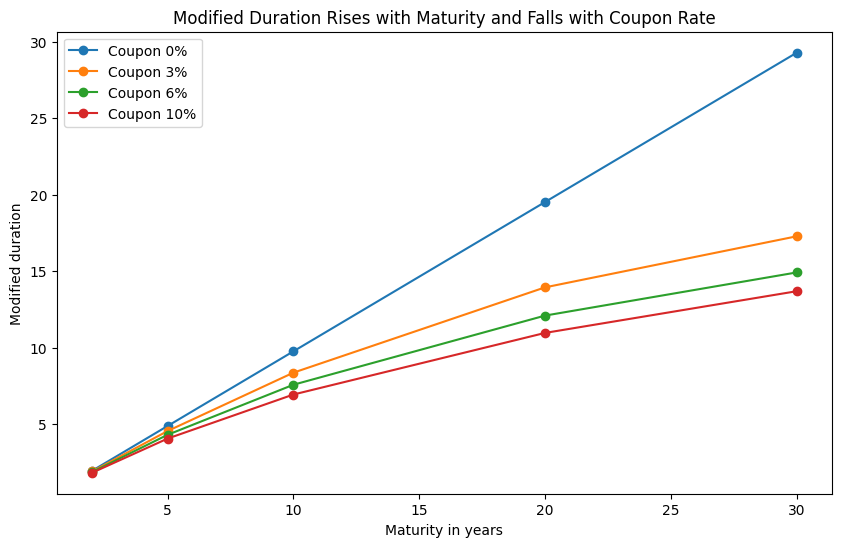

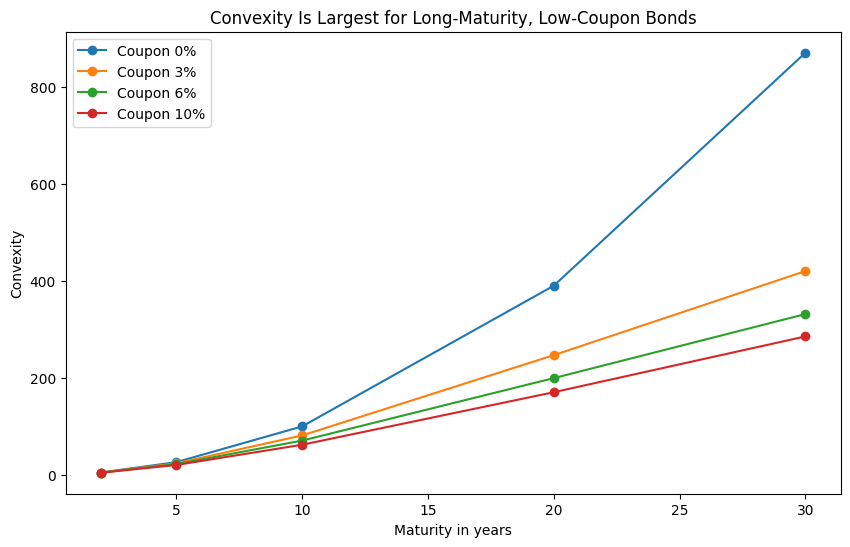

In [22]:

# How coupon and maturity influence duration and convexity.
comparison_rows = []
for maturity in [2, 5, 10, 20, 30]:
    for coupon_rate in [0.00, 0.03, 0.06, 0.10]:
        P, mac, mod, conv = bond_duration_convexity(1000, coupon_rate, 0.05, maturity, 2)
        comparison_rows.append({
            "Maturity": maturity,
            "Coupon rate": coupon_rate,
            "Price": P,
            "Modified duration": mod,
            "Convexity": conv
        })
comparison_df = pd.DataFrame(comparison_rows)

fig, ax = plt.subplots(figsize=(10, 6))
for coupon_rate, group in comparison_df.groupby("Coupon rate"):
    ax.plot(group["Maturity"], group["Modified duration"], marker='o', label=f"Coupon {coupon_rate:.0%}")
ax.set_title("Modified Duration Rises with Maturity and Falls with Coupon Rate")
ax.set_xlabel("Maturity in years")
ax.set_ylabel("Modified duration")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
for coupon_rate, group in comparison_df.groupby("Coupon rate"):
    ax.plot(group["Maturity"], group["Convexity"], marker='o', label=f"Coupon {coupon_rate:.0%}")
ax.set_title("Convexity Is Largest for Long-Maturity, Low-Coupon Bonds")
ax.set_xlabel("Maturity in years")
ax.set_ylabel("Convexity")
ax.legend()
plt.show()


## 13. The term structure of interest rates

The yield curve plots yields against maturities. A standard decomposition is

$$
\text{Nominal yield}_{n,t} \approx \text{expected average real short rate} + \text{expected average inflation} + \text{term premium}.
$$

Under the expectations hypothesis, a long yield equals the average expected future short rates, up to a term premium:

$$
y_{n,t} \approx \frac{1}{n}\sum_{j=0}^{n-1} E_t(i_{t+j}) + TP_{n,t}.
$$

In practice, yield curves are often summarized by three empirical factors:

1. **Level:** the general height of rates.
2. **Slope:** the difference between long and short rates.
3. **Curvature:** whether medium-term rates are high or low relative to short and long rates.


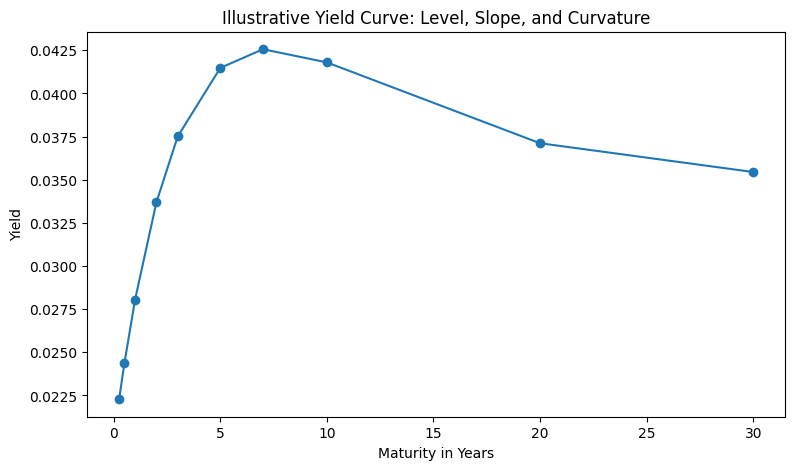

   Maturity  Yield
0    0.2500 0.0223
1    0.5000 0.0244
2    1.0000 0.0281
3    2.0000 0.0337
4    3.0000 0.0375
5    5.0000 0.0415
6    7.0000 0.0426
7   10.0000 0.0418
8   20.0000 0.0371
9   30.0000 0.0354


In [23]:
maturities = np.array([0.25, .5, 1, 2, 3, 5, 7, 10, 20, 30])
level = 0.035
slope = -0.015 * np.exp(-maturities/5)
curvature = 0.012 * (maturities/5) * np.exp(1 - maturities/5)
yield_curve = level + slope + curvature

plt.figure(figsize=(9,5))
plt.plot(maturities, yield_curve, marker='o')
plt.title('Illustrative Yield Curve: Level, Slope, and Curvature')
plt.xlabel('Maturity in Years')
plt.ylabel('Yield')
plt.show()

term_structure = pd.DataFrame({'Maturity': maturities, 'Yield': yield_curve})
print(term_structure)



### 13.1 A more careful term-structure framework

For a default-free nominal bond, the nominal yield can be decomposed approximately as

$$
y_n \approx r_n^{real}+\pi_n^e+TP_n,
$$

where $r_n^{real}$ is the real rate over horizon $n$, $\pi_n^e$ is expected inflation over that horizon, and $TP_n$ is the term premium required for bearing interest-rate risk. For corporate bonds, we add additional components:

$$
y_n^{corp}\approx r_n^{real}+\pi_n^e+TP_n+CS_n+LP_n+Tax_n,
$$

where $CS_n$ is the credit spread, $LP_n$ is a liquidity premium, and $Tax_n$ captures tax effects.

A standard expectations-hypothesis relationship says that the $n$-period yield is approximately the average of expected future short rates plus a term premium:

$$
y_{n,t}\approx \frac{1}{n}\sum_{j=0}^{n-1}E_t(i_{t+j})+TP_{n,t}.
$$

The same logic can be expressed through spot and forward rates. With annual compounding,

$$
(1+s_2)^2=(1+s_1)(1+f_{1,1}),
$$

so the one-year forward rate beginning one year from now is

$$
f_{1,1}=\frac{(1+s_2)^2}{1+s_1}-1.
$$

Empirically, yield curves are often summarized by three movements:

1. **Level**: parallel shifts in all yields.
2. **Slope**: short rates rising relative to long rates, or vice versa.
3. **Curvature**: middle maturities moving differently from short and long maturities.

A convenient parametric model is the Nelson-Siegel curve:

$$
y(\tau)=\beta_0+\beta_1\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}\right)+\beta_2\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right).
$$

Here $\beta_0$ mainly controls level, $\beta_1$ mainly controls slope, and $\beta_2$ mainly controls curvature.


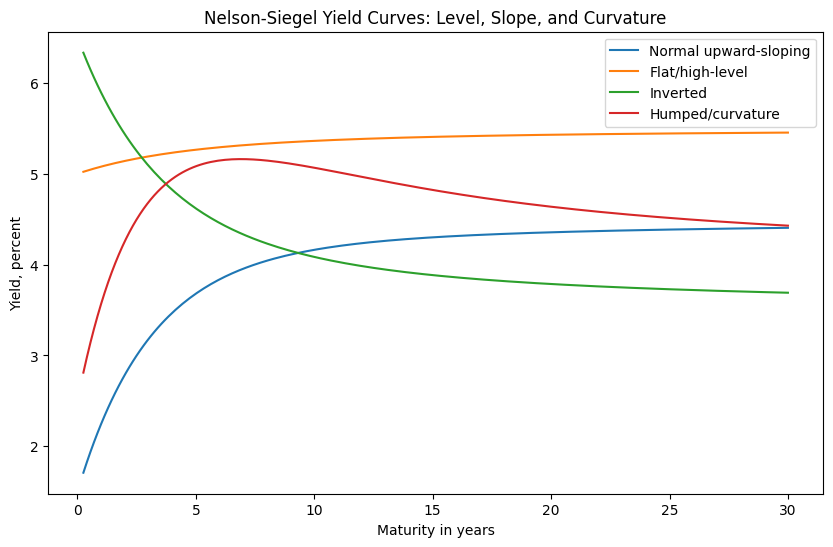

In [24]:

def nelson_siegel(tau, beta0, beta1, beta2, lam):
    tau = np.asarray(tau, dtype=float)
    factor1 = (1 - np.exp(-lam * tau)) / (lam * tau)
    factor2 = factor1 - np.exp(-lam * tau)
    return beta0 + beta1 * factor1 + beta2 * factor2

maturities = np.linspace(0.25, 30, 200)
curves = {
    "Normal upward-sloping": (0.045, -0.030, 0.020, 0.35),
    "Flat/high-level": (0.055, -0.005, 0.000, 0.35),
    "Inverted": (0.035, 0.030, -0.010, 0.35),
    "Humped/curvature": (0.040, -0.015, 0.060, 0.35)
}

plt.figure(figsize=(10, 6))
for label, params in curves.items():
    plt.plot(maturities, nelson_siegel(maturities, *params) * 100, label=label)
plt.title("Nelson-Siegel Yield Curves: Level, Slope, and Curvature")
plt.xlabel("Maturity in years")
plt.ylabel("Yield, percent")
plt.legend()
plt.show()


   Maturity  Real rate  Expected inflation  Term premium  Nominal yield
0         1     0.0127              0.0231        0.0028         0.0386
1         2     0.0133              0.0224        0.0035         0.0393
2         3     0.0139              0.0219        0.0042         0.0400
3         5     0.0148              0.0211        0.0054         0.0413
4         7     0.0155              0.0207        0.0064         0.0426
5        10     0.0163              0.0203        0.0077         0.0443
6        20     0.0175              0.0200        0.0101         0.0476
7        30     0.0179              0.0200        0.0112         0.0490


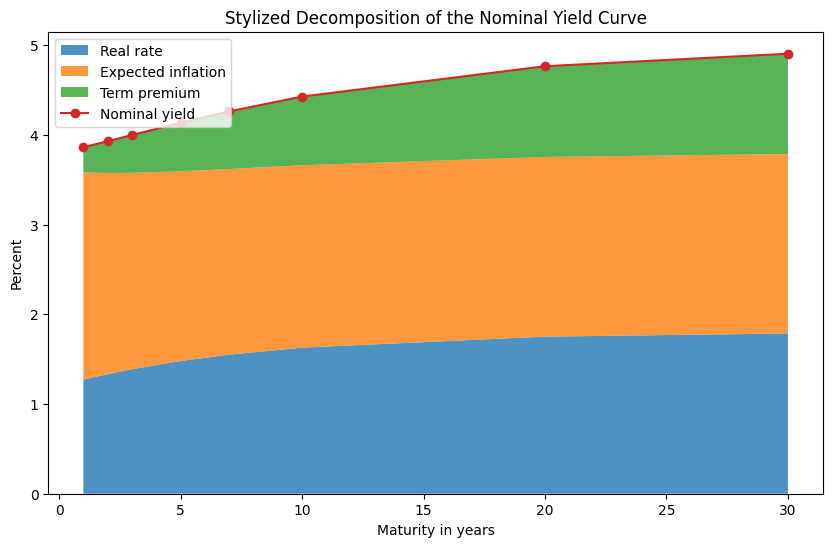

,Start,End,Implied forward rate
0,1,2,0.0400
1,2,3,0.0414
2,3,5,0.0434
3,5,7,0.0458
4,7,10,0.0481
5,10,20,0.0510
6,20,30,0.0518


In [25]:

# Decompose a stylized nominal Treasury yield curve into real rate, expected inflation, and term premium.
selected_maturities = np.array([1, 2, 3, 5, 7, 10, 20, 30])
real_rate = 0.012 + 0.006 * (1 - np.exp(-selected_maturities / 8))
expected_inflation = 0.020 + 0.004 * np.exp(-selected_maturities / 4)
term_premium = 0.002 + 0.010 * (1 - np.exp(-selected_maturities / 12))
nominal_yield = real_rate + expected_inflation + term_premium

decomp = pd.DataFrame({
    "Maturity": selected_maturities,
    "Real rate": real_rate,
    "Expected inflation": expected_inflation,
    "Term premium": term_premium,
    "Nominal yield": nominal_yield
})
print(decomp)

plt.figure(figsize=(10, 6))
plt.stackplot(selected_maturities, real_rate*100, expected_inflation*100, term_premium*100,
              labels=["Real rate", "Expected inflation", "Term premium"], alpha=0.8)
plt.plot(selected_maturities, nominal_yield*100, marker='o', label="Nominal yield")
plt.title("Stylized Decomposition of the Nominal Yield Curve")
plt.xlabel("Maturity in years")
plt.ylabel("Percent")
plt.legend(loc="upper left")
plt.show()

# Implied one-year forward rates from spot rates.
spot = pd.Series(nominal_yield, index=selected_maturities)
forward_rows = []
for n1, n2 in zip(selected_maturities[:-1], selected_maturities[1:]):
    s1, s2 = spot.loc[n1], spot.loc[n2]
    f = ((1+s2)**n2 / (1+s1)**n1)**(1/(n2-n1)) - 1
    forward_rows.append({"Start": n1, "End": n2, "Implied forward rate": f})
pd.DataFrame(forward_rows)


## 14. Bond arbitrage examples

When there are no arbitrage opportunities, bonds with identical cash flows must have identical prices. More generally, a coupon bond's price should equal the sum of zero-coupon components.

Suppose one-year and two-year zero-coupon bonds have prices $P_1$ and $P_2$. A two-year annual coupon bond paying coupon $C$ and face value $F$ should be priced as

$$
P_{coupon} = C P_1/F + (C+F)P_2/F
$$

when $P_1$ and $P_2$ are quoted per $F$ of face value. If the market coupon bond price differs from this synthetic price, one can buy the cheap package and sell the expensive one.


In [26]:
face = 1000
zero1_price = 952.38   # one-year zero at roughly 5%
zero2_price = 890.00   # two-year zero
coupon = 60
synthetic_coupon_price = (coupon/face)*zero1_price + ((coupon+face)/face)*zero2_price
market_coupon_price = 930
print(f"Synthetic coupon bond price: ${synthetic_coupon_price:,.2f}")
print(f"Market coupon bond price: ${market_coupon_price:,.2f}")

if market_coupon_price > synthetic_coupon_price:
    print("Arbitrage intuition: sell the overpriced coupon bond and buy the synthetic zero-coupon package.")
elif market_coupon_price < synthetic_coupon_price:
    print("Arbitrage intuition: buy the underpriced coupon bond and sell the synthetic zero-coupon package.")
else:
    print("No arbitrage: market price equals synthetic price.")


Synthetic coupon bond price: $1,000.54
Market coupon bond price: $930.00
Arbitrage intuition: buy the underpriced coupon bond and sell the synthetic zero-coupon package.



### 14.1 Cleaner bond-arbitrage examples: replication with zero-coupon bonds

The no-arbitrage price of a default-free bond is the cost of replicating its cash flows with zero-coupon bonds. Suppose a two-year coupon bond pays $60$ in one year and $1{,}060$ in two years. If the one-year spot rate is $s_1$ and the two-year spot rate is $s_2$, the arbitrage-free price is

$$
P^*=\frac{60}{1+s_1}+\frac{1060}{(1+s_2)^2}.
$$

If the market price is above $P^*$, the coupon bond is overpriced. An arbitrageur can short the coupon bond and buy the zero-coupon bonds needed to make the promised payments. If the market price is below $P^*$, the coupon bond is underpriced. An arbitrageur can buy the coupon bond and short the replicating zero-coupon portfolio.


In [27]:

# Zero-coupon replication of a two-year coupon bond.
s1 = 0.045
s2 = 0.052
cf1 = 60
cf2 = 1060
replication_cost = cf1/(1+s1) + cf2/(1+s2)**2
market_prices = [replication_cost - 15, replication_cost, replication_cost + 15]

arb_rows = []
for market_price in market_prices:
    if market_price > replication_cost:
        strategy = "Short coupon bond; buy zeros"
        arbitrage_profit = market_price - replication_cost
    elif market_price < replication_cost:
        strategy = "Buy coupon bond; short zeros"
        arbitrage_profit = replication_cost - market_price
    else:
        strategy = "No arbitrage"
        arbitrage_profit = 0
    arb_rows.append({
        "Coupon bond market price": market_price,
        "Replicating zero-bond cost": replication_cost,
        "Strategy": strategy,
        "Arbitrage profit today": arbitrage_profit
    })

pd.DataFrame(arb_rows)


,Coupon bond market price,Replicating zero-bond cost,Strategy,Arbitrage profit today
0,"1,000.2153","1,015.2153",Buy coupon bond; short zeros,15.0000
1,"1,015.2153","1,015.2153",No arbitrage,0.0000
2,"1,030.2153","1,015.2153",Short coupon bond; buy zeros,15.0000


In [28]:

# Cash-flow table for the overpriced case: short coupon bond, buy zeros.
market_price = replication_cost + 15
units_zero_1 = cf1 / 1000       # one-year zero with face value 1000
units_zero_2 = cf2 / 1000       # two-year zero with face value 1000
price_zero_1 = 1000 / (1+s1)
price_zero_2 = 1000 / (1+s2)**2
cash_today = market_price - units_zero_1 * price_zero_1 - units_zero_2 * price_zero_2

cashflow_table = pd.DataFrame({
    "Date": [0, 1, 2],
    "Short coupon bond": [market_price, -cf1, -cf2],
    "Buy one-year zero": [-units_zero_1 * price_zero_1, units_zero_1 * 1000, 0],
    "Buy two-year zero": [-units_zero_2 * price_zero_2, 0, units_zero_2 * 1000]
})
cashflow_table["Net cash flow"] = cashflow_table.iloc[:, 1:].sum(axis=1)
print(f"Arbitrage profit today: ${cash_today:,.2f}")
cashflow_table


Arbitrage profit today: $15.00


,Date,Short coupon bond,Buy one-year zero,Buy two-year zero,Net cash flow
0,0,"1,030.2153",-57.4163,-957.7990,15.0000
1,1,-60.0000,60.0000,0.0000,0.0000
2,2,"-1,060.0000",0.0000,"1,060.0000",0.0000


In [29]:

# A yield-curve arbitrage illustration using forward rates.
# If a quoted forward loan rate differs from the rate implied by spot rates, borrow/lend synthetically.
s1 = 0.04
s2 = 0.05
implied_forward = (1+s2)**2 / (1+s1) - 1
quoted_forward = 0.075  # too high relative to spot-implied forward

print(f"Spot-implied 1-year forward rate, year 1 to year 2: {implied_forward:.2%}")
print(f"Quoted forward rate: {quoted_forward:.2%}")

# Arbitrage if quoted forward is too high: agree to lend forward at quoted rate.
# Replicate funding by borrowing for 2 years and lending for 1 year today.
notional_forward = 1000
profit_at_t2 = notional_forward * ((1 + quoted_forward) / (1 + implied_forward) - 1)
print(f"Approximate riskless profit at t=2 per $1,000 forward notional: ${profit_at_t2:,.2f}")


Spot-implied 1-year forward rate, year 1 to year 2: 6.01%
Quoted forward rate: 7.50%
Approximate riskless profit at t=2 per $1,000 forward notional: $14.06


## 15. Summary

The time value of money is the foundation of bond pricing and capital budgeting. Non-constant cash flows, annuities, perpetuities, growing perpetuities, and bonds are not separate valuation theories. They are all applications of the same present value rule.

Bonds add institutional detail: coupon frequency, yield conventions, credit spreads, default risk, duration, convexity, and the term structure. These details matter because fixed-income securities are claims to dated cash flows, and their values are therefore highly sensitive to discount rates, inflation expectations, and risk premia.
